# HPO Results Analysis

This notebook analyzes the hyperparameter search results in `FINAL-FOLDER-OFF/hpo_results.csv` and builds a set of matplotlib charts to compare model families and hyperparameters.

In [28]:
from collections import defaultdict
from pathlib import Path
import csv
import math
import statistics

import matplotlib.pyplot as plt

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

DATA_SOURCES = [
    (Path('/Users/olliglorioso/Documents/ML4CO/starting_kit/FINAL-FOLDER-OFF/hpo_results.csv'), None),
    (Path('/Users/olliglorioso/Documents/ML4CO/starting_kit/hpo_results_gsage.csv'), 'GSAGE'),
]

NUMERIC_COLUMNS = {
    'trial': int,
    'hidden_channels': int,
    'num_layers': int,
    'lr': float,
    'batch_size': int,
    'epochs': int,
    'early_stopping': int,
    'dropout': float,
    'val_loss': float,
}

def load_rows(path: Path, force_model_type=None):
    with path.open(newline='') as handle:
        reader = csv.DictReader(handle)
        rows = []
        for row in reader:
            parsed = {}
            for key, value in row.items():
                converter = NUMERIC_COLUMNS.get(key)
                parsed[key] = converter(value) if converter else value
            if force_model_type is not None:
                parsed['model_type'] = force_model_type
            rows.append(parsed)
    return rows

rows = []
for data_path, forced_model_type in DATA_SOURCES:
    rows.extend(load_rows(data_path, force_model_type=forced_model_type))

len(rows)


360

In [29]:
def group_values(rows, key):
    grouped = defaultdict(list)
    for row in rows:
        grouped[row[key]].append(row['val_loss'])
    return grouped

def summarize(rows, *keys):
    grouped = defaultdict(list)
    for row in rows:
        grouped[tuple(row[key] for key in keys)].append(row['val_loss'])
    summary = []
    for combo, losses in grouped.items():
        item = {key: value for key, value in zip(keys, combo)}
        item['count'] = len(losses)
        item['mean_val_loss'] = statistics.mean(losses)
        item['median_val_loss'] = statistics.median(losses)
        item['best_val_loss'] = min(losses)
        summary.append(item)
    return sorted(summary, key=lambda item: item['mean_val_loss'])

best_run = min(rows, key=lambda row: row['val_loss'])
model_summary = summarize(rows, 'model_type')
top_runs = sorted(rows, key=lambda row: row['val_loss'])[:10]

print(f'Total trials: {len(rows)}')
print(f'Validation loss range: {min(r['val_loss'] for r in rows):.2f} to {max(r['val_loss'] for r in rows):.2f}')
print('\nBest run:')
for key, value in best_run.items():
    print(f'  {key}: {value}')

print('\nModel family summary:')
for item in model_summary:
    print(item)

print('\nTop 10 runs:')
for row in top_runs:
    print(row)

Total trials: 360
Validation loss range: 66.72 to 298.32

Best run:
  trial: 25
  model_type: GSAGE
  hidden_channels: 256
  num_layers: 6
  lr: 0.001
  batch_size: 8
  epochs: 150
  early_stopping: 30
  dropout: 0.2
  val_loss: 66.72032440185546

Model family summary:
{'model_type': 'GSAGE', 'count': 36, 'mean_val_loss': 68.5734160232544, 'median_val_loss': 68.81504653930665, 'best_val_loss': 66.72032440185546}
{'model_type': 'GAT', 'count': 162, 'mean_val_loss': 89.33989565343033, 'median_val_loss': 90.82440719604492, 'best_val_loss': 69.48089752197265}
{'model_type': 'GIN', 'count': 162, 'mean_val_loss': 99.79675893712927, 'median_val_loss': 83.07854293823243, 'best_val_loss': 74.53615539550782}

Top 10 runs:
{'trial': 25, 'model_type': 'GSAGE', 'hidden_channels': 256, 'num_layers': 6, 'lr': 0.001, 'batch_size': 8, 'epochs': 150, 'early_stopping': 30, 'dropout': 0.2, 'val_loss': 66.72032440185546}
{'trial': 26, 'model_type': 'GSAGE', 'hidden_channels': 256, 'num_layers': 6, 'lr': 0.

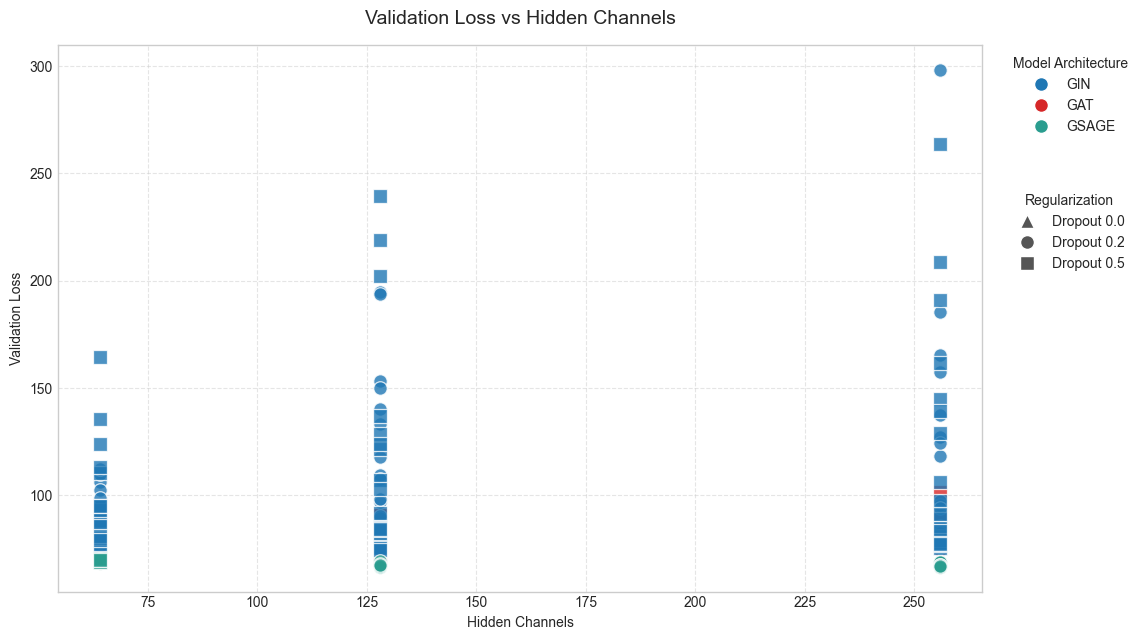

In [30]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

palette = {'GIN': '#1f77b4', 'GAT': '#d62728', 'GSAGE': '#2a9d8f'}
markers = {0.0: '^', 0.2: 'o', 0.5: 's'}

fig, ax = plt.subplots(figsize=(11.5, 6.5))

# 1. Plot the data (removed the dynamic label string to keep the automatic legend empty)
for model_type in sorted({row['model_type'] for row in rows}):
    for dropout in sorted({row['dropout'] for row in rows if row['model_type'] == model_type}):
        subset = [row for row in rows if row['model_type'] == model_type and row['dropout'] == dropout]
        ax.scatter(
            [row['hidden_channels'] for row in subset],
            [row['val_loss'] for row in subset],
            s=95,
            alpha=0.8,
            c=palette[model_type],
            marker=markers.get(dropout, 'o'),
            edgecolors='white',
            linewidths=0.9,
        )

# 2. Define custom legend handles
model_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=model)
    for model, color in palette.items()
]

dropout_handles = [
    Line2D([0], [0], marker=marker, color='w', markerfacecolor='#555555', markersize=10, label=f'Dropout {do}')
    for do, marker in markers.items()
]

# 3. Add both legends to the plot
# We must manually add the first legend back because a second ax.legend() call overwrites the first one
model_legend = ax.legend(handles=model_handles, title="Model Architecture", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.add_artist(model_legend) 

ax.legend(handles=dropout_handles, title="Regularization", loc="upper left", bbox_to_anchor=(1.02, 0.75))

ax.set_title('Validation Loss vs Hidden Channels', fontsize=14, pad=15)
ax.set_xlabel('Hidden Channels')
ax.set_ylabel('Validation Loss')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

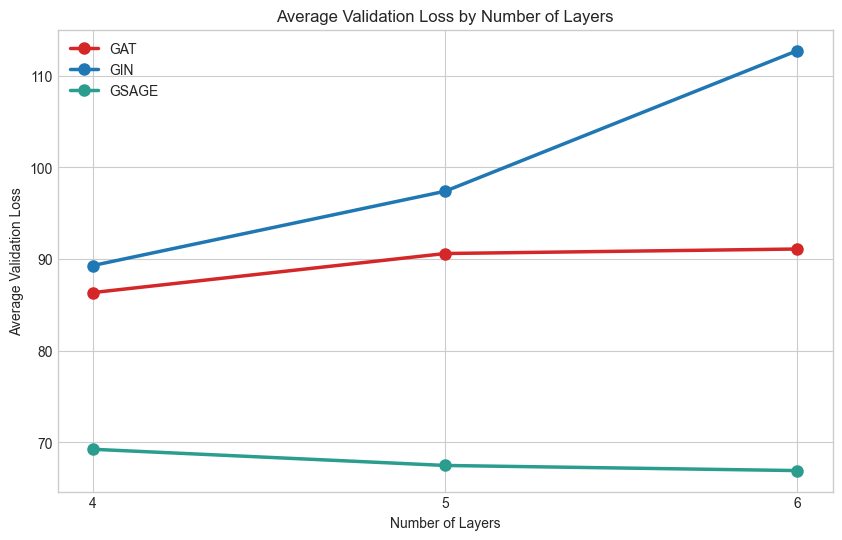

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
for model_type in sorted({row['model_type'] for row in rows}):
    layer_values = []
    mean_losses = []
    for num_layers in sorted({row['num_layers'] for row in rows}):
        losses = [row['val_loss'] for row in rows if row['model_type'] == model_type and row['num_layers'] == num_layers]
        if losses:
            layer_values.append(num_layers)
            mean_losses.append(statistics.mean(losses))
    ax.plot(layer_values, mean_losses, marker='o', linewidth=2.5, markersize=8, color=palette[model_type], label=model_type)

ax.set_title('Average Validation Loss by Number of Layers')
ax.set_xlabel('Number of Layers')
ax.set_ylabel('Average Validation Loss')
ax.set_xticks(sorted({row['num_layers'] for row in rows}))
ax.legend()
plt.show()

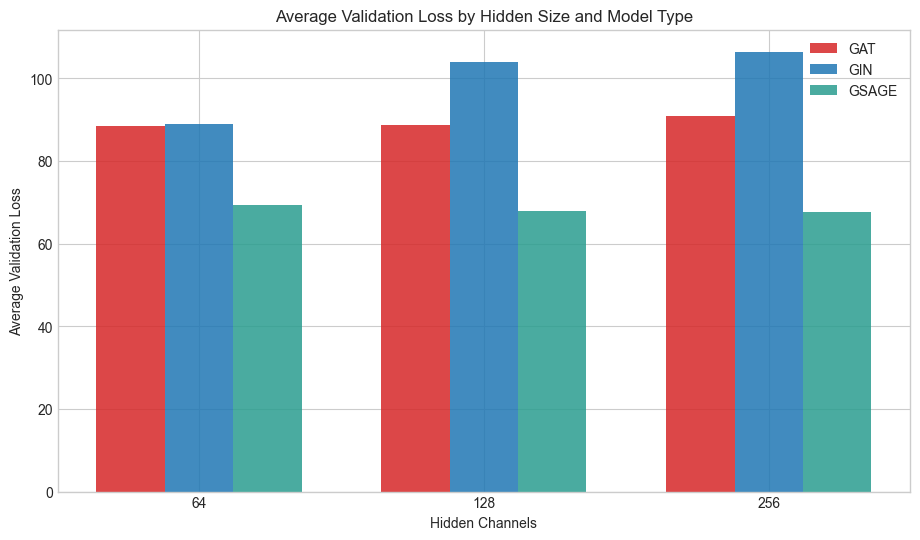

In [32]:
hidden_values = sorted({row['hidden_channels'] for row in rows})
model_types = sorted({row['model_type'] for row in rows})
x = range(len(hidden_values))
bar_width = 0.24
offsets = [index - (len(model_types) - 1) / 2 for index in range(len(model_types))]

fig, ax = plt.subplots(figsize=(11, 6))
for index, model_type in enumerate(model_types):
    means = []
    for hidden in hidden_values:
        losses = [row['val_loss'] for row in rows if row['model_type'] == model_type and row['hidden_channels'] == hidden]
        means.append(statistics.mean(losses) if losses else math.nan)
    positions = [value + offsets[index] * bar_width for value in x]
    ax.bar(positions, means, width=bar_width, color=palette[model_type], alpha=0.85, label=model_type)

ax.set_title('Average Validation Loss by Hidden Size and Model Type')
ax.set_xlabel('Hidden Channels')
ax.set_ylabel('Average Validation Loss')
ax.set_xticks(list(x))
ax.set_xticklabels(hidden_values)
ax.legend()
plt.show()


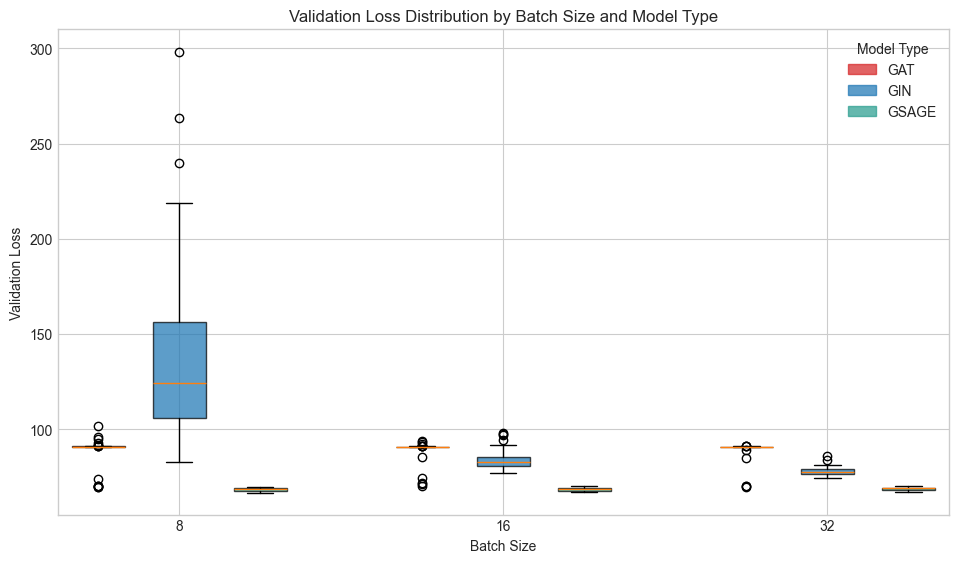

In [33]:
batch_sizes = sorted({row['batch_size'] for row in rows})
model_types = sorted({row['model_type'] for row in rows})
positions = []
boxplot_data = []
box_colors = []
tick_positions = []
tick_labels = []

group_width = len(model_types) + 1
for batch_index, batch_size in enumerate(batch_sizes):
    base = batch_index * group_width
    tick_positions.append(base + (len(model_types) - 1) / 2)
    tick_labels.append(str(batch_size))
    for model_index, model_type in enumerate(model_types):
        losses = [
            row['val_loss']
            for row in rows
            if row['batch_size'] == batch_size and row['model_type'] == model_type
        ]
        if losses:
            positions.append(base + model_index)
            boxplot_data.append(losses)
            box_colors.append(palette[model_type])

fig, ax = plt.subplots(figsize=(11.5, 6.3))
box = ax.boxplot(boxplot_data, positions=positions, widths=0.65, patch_artist=True)
for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.72)

ax.set_title('Validation Loss Distribution by Batch Size and Model Type')
ax.set_xlabel('Batch Size')
ax.set_ylabel('Validation Loss')
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=palette[model_type], alpha=0.72) for model_type in model_types]
ax.legend(legend_handles, model_types, title='Model Type')
plt.show()


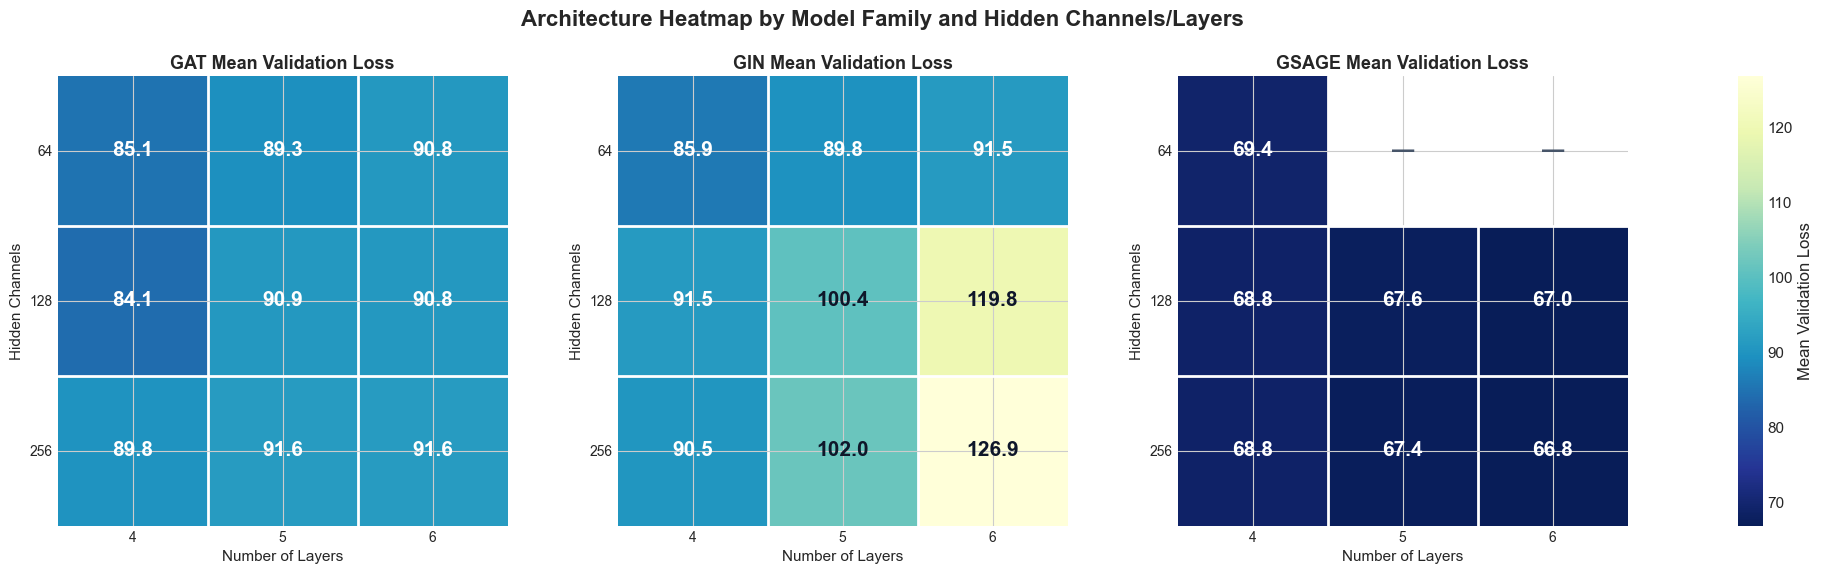

In [34]:
layer_values = sorted({row['num_layers'] for row in rows})
hidden_values = sorted({row['hidden_channels'] for row in rows})
model_types = sorted({row['model_type'] for row in rows})
heatmaps = {}

for model_type in model_types:
    heatmap = []
    for hidden in hidden_values:
        row_values = []
        for num_layers in layer_values:
            losses = [
                row['val_loss']
                for row in rows
                if row['model_type'] == model_type
                and row['hidden_channels'] == hidden
                and row['num_layers'] == num_layers
            ]
            row_values.append(statistics.mean(losses) if losses else math.nan)
        heatmap.append(row_values)
    heatmaps[model_type] = heatmap

all_values = [value for heatmap in heatmaps.values() for row in heatmap for value in row if not math.isnan(value)]
vmin, vmax = min(all_values), max(all_values)

fig = plt.figure(figsize=(22, 6), facecolor='white')
grid = fig.add_gridspec(1, len(model_types) + 1, width_ratios=[1] * len(model_types) + [0.055], wspace=0.32)
axes = [fig.add_subplot(grid[0, idx]) for idx in range(len(model_types))]
for ax in axes[1:]:
    ax.sharey(axes[0])
cax = fig.add_subplot(grid[0, len(model_types)])

for ax, model_type in zip(axes, model_types):
    heatmap = heatmaps[model_type]
    image = ax.imshow(heatmap, cmap='YlGnBu_r', aspect='equal', vmin=vmin, vmax=vmax)

    ax.set_title(f'{model_type} Mean Validation Loss', fontsize=13, pad=5, fontweight='semibold')
    ax.set_xlabel('Number of Layers', fontsize=11)
    ax.set_xticks(range(len(layer_values)))
    ax.set_xticklabels(layer_values, fontsize=10)
    ax.set_yticks(range(len(hidden_values)))
    ax.set_yticklabels(hidden_values, fontsize=10)
    ax.set_ylabel('Hidden Channels', fontsize=11)

    ax.set_xticks([x - 0.5 for x in range(1, len(layer_values))], minor=True)
    ax.set_yticks([y - 0.5 for y in range(1, len(hidden_values))], minor=True)
    ax.grid(which='minor', color='white', linestyle='-', linewidth=2)
    ax.tick_params(which='minor', bottom=False, left=False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    midpoint = (vmin + vmax) / 2
    for y, hidden in enumerate(hidden_values):
        for x_index, num_layers in enumerate(layer_values):
            value = heatmap[y][x_index]
            if math.isnan(value):
                ax.text(x_index, y, '—', ha='center', va='center', color='#475569', fontsize=16, fontweight='semibold')
            else:
                text_color = '#0f172a' if value >= midpoint else 'white'
                ax.text(
                    x_index,
                    y,
                    f'{value:.1f}',
                    ha='center',
                    va='center',
                    color=text_color,
                    fontsize=15,
                    fontweight='semibold',
                )

colorbar = fig.colorbar(image, cax=cax)
colorbar.set_label('Mean Validation Loss', fontsize=12)
colorbar.ax.tick_params(labelsize=11)
colorbar.outline.set_visible(False)

fig.suptitle('Architecture Heatmap by Model Family and Hidden Channels/Layers', fontsize=16, fontweight='bold', y=0.98)
plt.subplots_adjust(top=0.87, bottom=0.12)
plt.show()


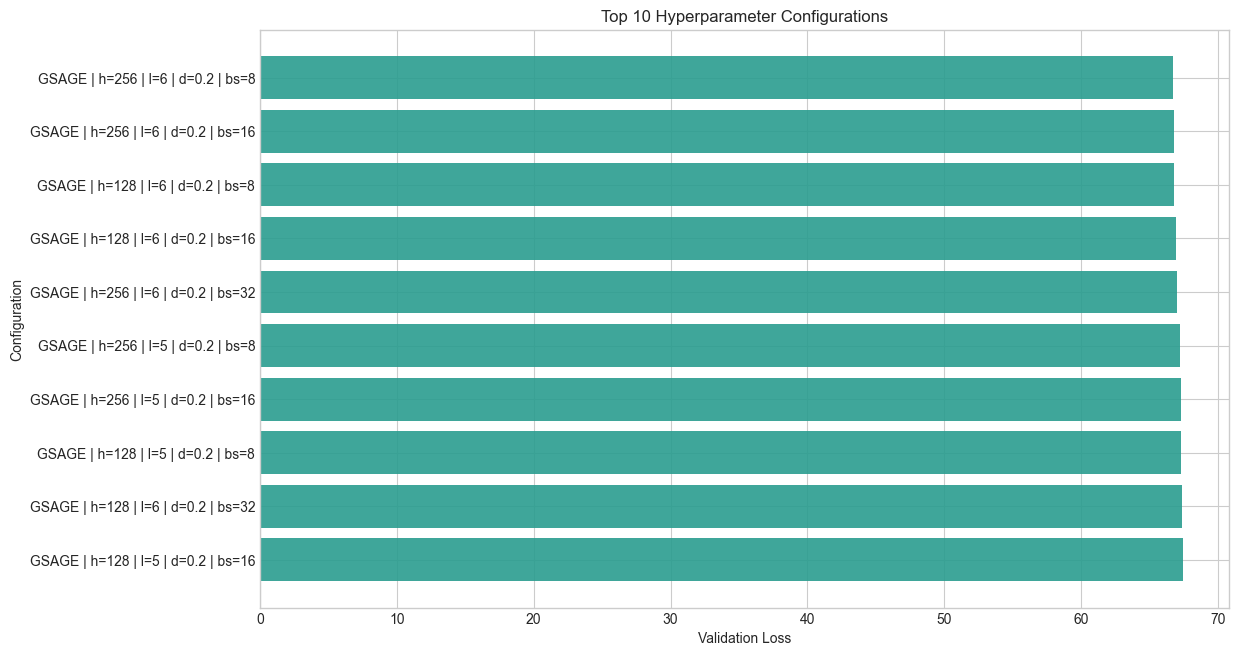

In [35]:
top_runs = sorted(rows, key=lambda row: row['val_loss'])[:10]
labels = [
    f"{row['model_type']} | h={row['hidden_channels']} | l={row['num_layers']} | d={row['dropout']} | bs={row['batch_size']}"
    for row in top_runs
]
losses = [row['val_loss'] for row in top_runs]

fig, ax = plt.subplots(figsize=(12.5, 7.5))
colors = [palette[row['model_type']] for row in top_runs]
ax.barh(labels[::-1], losses[::-1], color=colors[::-1], alpha=0.9)
ax.set_title('Top 10 Hyperparameter Configurations')
ax.set_xlabel('Validation Loss')
ax.set_ylabel('Configuration')
plt.show()


,model_type,rank,val_loss,hidden_channels,num_layers,batch_size
62,GAT,1,69.48,64,5,8
122,GAT,2,69.54,128,4,8
142,GAT,3,69.76,128,4,32
213,GIN,1,74.54,128,6,32
201,GIN,2,75.28,128,6,32
129,GIN,3,75.56,128,4,32
357,GSAGE,1,66.72,256,6,8
358,GSAGE,2,66.77,256,6,16
348,GSAGE,3,66.82,128,6,8


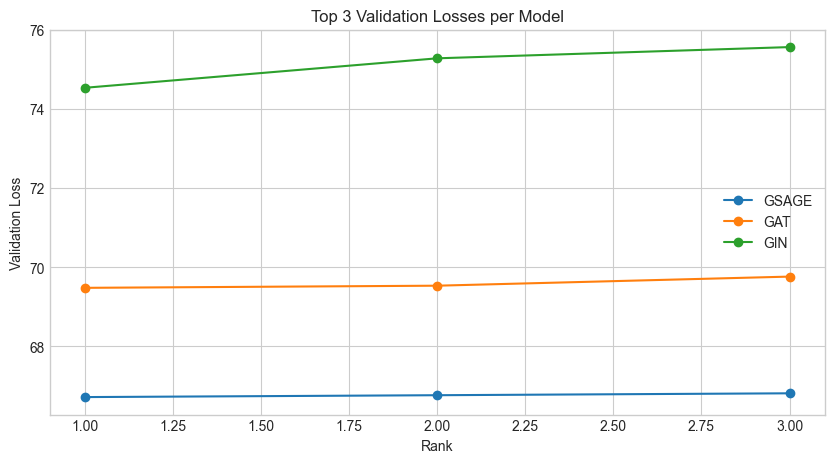

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Create dataframe
df = pd.DataFrame(rows)

# Get top 3 per model
top_per_model = (
    df.sort_values('val_loss')
      .groupby('model_type')
      .head(3)
      .copy()
)

# Rank inside each model
top_per_model['rank'] = (
    top_per_model.groupby('model_type')['val_loss']
                 .rank(method='first')
                 .astype(int)
)

# Pretty display
display_columns = [
    'model_type',
    'rank',
    'val_loss',
    'hidden_channels',
    'num_layers',
    'batch_size',
]

styled = (
    top_per_model[display_columns]
    .sort_values(['model_type', 'rank'])
    .style
    .background_gradient(subset=['val_loss'], cmap='RdYlGn_r')
    .format({
        'val_loss': '{:.2f}',
        'lr': '{:.1e}',
        'dropout': '{:.2f}',
    })
    .set_caption('Top 3 HPO Results per Model')
)

display(styled)

# ---- Visualization ----

fig, ax = plt.subplots(figsize=(10, 5))

for model_type in top_per_model['model_type'].unique():
    subset = top_per_model[top_per_model['model_type'] == model_type]
    
    ax.plot(
        subset['rank'],
        subset['val_loss'],
        marker='o',
        label=model_type
    )

ax.set_xlabel('Rank')
ax.set_ylabel('Validation Loss')
ax.set_title('Top 3 Validation Losses per Model')
ax.legend()
plt.show()